# FigA — leave-one-state-out, linear duration effect


**Input columns:** `crop, dropped, model, nobs, b, se, p, pct, pct_lo, pct_hi`
where `pct` is the duration effect in %/yr, `pct_lo`/`pct_hi` are its 95% CI
bounds, and the row with `dropped == "none"` is the full-sample estimate.

**What the figure shows.** One row per dropped state, ordered by state size, with
the full-sample estimate as a dashed orange reference. Bars are 95% CIs
(county-clustered). Estimated on the published specification: rainfed fields,
early adopters omitted, clean controls or continuous low-till spells,
area-weighted, field + year fixed effects.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display

# ---- inputs / outputs -------------------------------------------------------
CSV     = "../output_linear_1999_2023/8_leave_one_state_out/8_loo_linear.csv"        # <-- path to the estimates
OUT_PNG = "FigA_loo_linear.png"
OUT_PDF = "FigA_loo_linear.pdf"

# ---- palette: colourblind-safe categorical slots 1-2, plus neutrals ---------
# blue/orange validated all-pairs on a light surface: CVD dE 24.7, normal 33.6,
# both >= 3:1 contrast. Grey/ink tones are neutrals, not categorical hues.
BLUE, ORANGE, GRAY    = "#2a78d6", "#eb6834", "#b9b9b4"
INK, INK2, MUTE, GRID = "#0b0b0b", "#52514e", "#8a8a86", "#e6e6e2"
CROP_LAB = {"corn": "Corn", "soy": "Soybean"}


## Load and derive the row order

The row order is the **size of the dropped state**, largest at top, recovered
from the observation counts (`full nobs − nobs`). Using one shared order for both
panels — rather than sorting each panel by its own estimate — keeps a given state
on the same row in both, so they can be read across.

In [2]:
df = pd.read_csv(CSV)

# full-sample reference, CI, and total obs, per crop
full  = df[df["dropped"] == "none"].set_index("crop")
ref   = full["pct"].to_dict()
ref_lo = full["pct_lo"].to_dict()
ref_hi = full["pct_hi"].to_dict()
fulln = full["nobs"].to_dict()

loo = df[df["dropped"] != "none"].copy()
loo["dropped_obs"] = [fulln[c] - n for c, n in zip(loo["crop"], loo["nobs"])]

# shared row order: largest dropped state at the top
order = (loo.groupby("dropped")["dropped_obs"].max()
            .sort_values(ascending=False).index.tolist())
ypos = {s: len(order) - 1 - i for i, s in enumerate(order)}   # 0 = bottom row

rng = loo.groupby("crop")["pct"].agg(["min", "max"])
print("row order (top -> bottom):", order)
print("full-sample reference   :", {k: round(v, 4) for k, v in ref.items()})
print("full-sample 95% CI      :", {k: (round(ref_lo[k], 4), round(ref_hi[k], 4)) for k in ref})
print(rng.round(4))


row order (top -> bottom): ['IA', 'IL', 'MN', 'WI', 'OH', 'IN', 'MO', 'SD', 'MI']
full-sample reference   : {'corn': 0.1986, 'soy': 0.1592}
full-sample 95% CI      : {'corn': (0.1457, 0.2514), 'soy': (0.1163, 0.2021)}
         min     max
crop                
corn  0.1674  0.2358
soy   0.1224  0.1837


## Draw

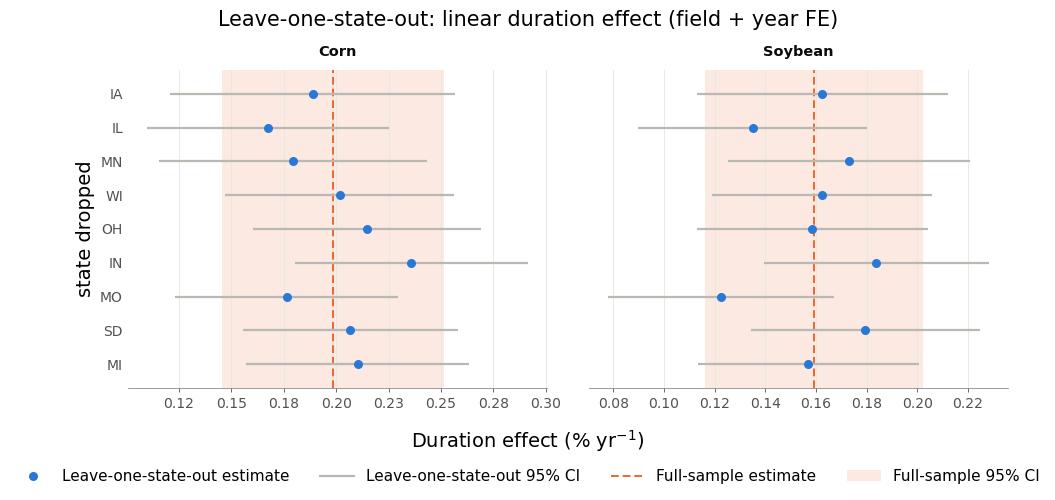

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

for ax, crop in zip(axes, ["corn", "soy"]):
    d = loo[loo["crop"] == crop]
    y = d["dropped"].map(ypos).to_numpy()

    ax.axvspan(ref_lo[crop], ref_hi[crop], color=ORANGE, alpha=0.14, lw=0, zorder=0)
    ax.axvline(ref[crop], color=ORANGE, lw=1.4, ls=(0, (4, 2)), zorder=1)
    ax.hlines(y, d["pct_lo"], d["pct_hi"], color=GRAY, lw=1.6, zorder=2)
    ax.plot(d["pct"], y, "o", color=BLUE, ms=6.5, mew=0, zorder=3)

    ax.set_title(CROP_LAB[crop], fontsize=10.5, fontweight="bold", color=INK, pad=10)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([order[len(order) - 1 - i] for i in range(len(order))])
    ax.set_ylim(-0.7, len(order) - 0.3)

    ax.xaxis.grid(True, color=GRID, lw=0.6)      # recessive grid, vertical only
    ax.yaxis.grid(False)
    ax.set_axisbelow(True)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(MUTE)
    ax.spines["bottom"].set_linewidth(0.6)
    ax.tick_params(colors=INK2, labelsize=10, length=3, width=0.6)
    ax.tick_params(axis="y", length=0)           # no tick dashes beside labels
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))

axes[0].set_ylabel("state dropped", fontsize=14)
fig.supxlabel("Duration effect (% yr$^{{-1}}$)", fontsize=14, y=0.11)

legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=BLUE,
           markeredgewidth=0, markersize=6.5, label="Leave-one-state-out estimate"),
    Line2D([0], [0], color=GRAY, lw=1.6, label="Leave-one-state-out 95% CI"),
    Line2D([0], [0], color=ORANGE, lw=1.4, ls=(0, (4, 2)), label="Full-sample estimate"),
    Patch(facecolor=ORANGE, alpha=0.14, edgecolor="none", label="Full-sample 95% CI"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.05),
    ncol=4,
    frameon=False,
    fontsize=11,
    handlelength=2.2,
    borderaxespad=0,
)

fig.suptitle("Leave-one-state-out: linear duration effect (field + year FE)",
             x=0.5, y=0.85, ha="center", fontsize=15)


fig.subplots_adjust(left=0.10, right=0.98, top=0.75, bottom=0.22, wspace=0.10)
plt.show()


## Save

In [4]:
fig.savefig(OUT_PNG, dpi=320)
fig.savefig(OUT_PDF)                 # vector, for the manuscript
print("wrote", OUT_PNG, "and", OUT_PDF)

wrote FigA_loo_linear.png and FigA_loo_linear.pdf
